<a href="https://colab.research.google.com/github/tnehezd/mesalab/blob/main/docs/colab_notebooks/mesalab_mesa_grid_base_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Tutorial: Running an Example Analysis in `mesalab` with Google Colab


This notebook will guide you through running a full `mesalab` analysis within a Google Colab environment. We'll set up `mesalab`, process a sample of real MESA data to identify specific stellar phenomena, and inspect the results.

The provided example data allows you to test `mesalab`'s core functionality for filtering MESA outputs **without** needing to install the MESA SDK, GYRE, or RSP.

----

### Prerequisites

* An active Google account (for Colab access).

----


> 💡 **Note** The pipeline is optimized for Python < 3.12! If you encounter any runtime errors, please check that your **Runtime version is set to 2025.07** under the **Notebook settings / Runtime type**. You can find this either in the *Edit -> Notebook settings* menu, or in the *Runtime -> Change runtime type* menu.

## 1.  Set up `mesalab` and Get Example Data

#### 1.1 Clone the ``mesalab`` repository

First, clone the `mesalab` repository from GitHub. This will give you access to the source code and the `example/` directory containing the sample MESA data and configuration files.

> 💡 **Note:** This step is a one-time operation per session.
> If you've already run this cell, you can skip it.


In [3]:
!git clone https://github.com/konkolyseismolab/mesalab

Cloning into 'mesalab'...
remote: Enumerating objects: 18410, done.
remote: Counting objects: 100% (156/156), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 18410 (delta 74), reused 93 (delta 39), pack-reused 18254 (from 3)
Receiving objects: 100% (18410/18410), 866.37 MiB | 16.65 MiB/s, done.
Resolving deltas: 100% (9611/9611), done.
Updating files: 100% (950/950), done.


----

#### 1.2 Install `mesalab` and its dependencies

Now, install `mesalab` and all its required Python packages.

> 💡 **Note:** This step is a one-time operation per session.
> If you've already run this cell, you can skip it.


> 💡 **Note on Environment & Dependencies:** > Since Python 3.11/3.12+ is pre-installed on modern Colab environments with a rigid AI/Deep Learning stack, we must force-reinstall specific legacy versions of the scientific computing core (`numpy==1.24.4`, `pandas==2.0.3`, `numba==0.57.1`) required by the MESA/GYRE analysis routines.
>
> ⚠️ **Regarding Dependency Resolver Errors:** > At the end of the installation step, `pip` will display several red `ERROR` messages regarding dependency conflicts (e.g., with `google-colab`, `jax`, or `tensorflow`). **These are internal Colab system warnings and can be safely ignored.** They do not affect `mesalab` in any way, as our code runs directly from the cloned repository using its own isolated, forced runtime environment.


In [4]:
!pip install --no-cache-dir mesalab

----

## 2. Examine the Example Data and Configuration


Once you have successfully installed the package, navigate to the `example/` directory within `mesalab/`.

In [5]:
# Navigate to the example track
%cd /content/mesalab/example


/content/mesalab/example


This directory contains two pre-defined datasets. In this tutorial, we will focus on the `MESA_grid` dataset, which consists of real stellar evolution outputs from MESA. It is designed to demonstrate `mesalab`'s core blue loop filtering and analysis capabilities.

#### 2.1. Dataset Overview

* **Grid Parameters**: The dataset includes a 2x2 grid of models with masses of 4 and 5 M⊙​ and metallicities (Z) of 0.0090 and 0.0100.

* **Evolutionary Coverage**: The simulations cover stellar evolution from the pre-main sequence (pre-MS) to a point after the blue loop phase.

* **Key Feature**: A defining characteristic of this dataset is the differing blue loop behavior: models with 5 M⊙​ exhibit blue loop crossings, while models with 4 M⊙​ do not.


This example dataset is located in the `example/MESA_grid` directory.

The corresponding `example_MESA_base.yaml` configuration file is set up to identify blue loop crossers and generate plots. It also prepares filtered output files, which can be used as input for a subsequent GYRE workflow.

## 3. Run the `MESA_grid` Example

You can easily run your first example by executing `mesalab` with the provided configuration file:

In [6]:
# Force matplotlib to headless mode for cloud rendering
import matplotlib
matplotlib.use('Agg')

# Run the local evolutionary track analyzer directly
!mesalab --config example_MESA_base.yaml


                    mesalab CLI - Starting Analysis Workflow                    
                                 Version: 2.2.0                                 

2026-06-02 15:09:04,785 - WARNING: PyMultiNest not imported.  MultiNest fits will not work.

       Starting MESA Analysis Workflow...

Performing MESA Run Analysis: 100% 4/4 [00:01<00:00,  3.05it/s]

       MESA Analysis Workflow Completed Successfully.


       MESA RSP workflow is disabled in configuration.


       Starting Plotting Workflow...


  Full Instability Strip Crossings Matrix (for Heatmap):
           4.0  5.0
initial_Z          
0.009      0.0  2.0
0.010      0.0  2.0

Calculating BCs serially: 100% 373/373 [00:01<00:00, 239.75it/s]
2026-06-02 15:09:12,549 - WARNING: No valid CMD plots for combined data after dropping NaNs in G_BP_minus_G_RP or M_G.

       Plotting Workflow Completed Successfully.


       GYRE workflow is disabled in configuration.


║                  mesalab Workflow Finished Successfull

## ⚠️ Note on Expected Output

The run is **successful**, but the following behavior is expected in this Colab environment:

### CMD (Color-Magnitude Diagram) is not generated
The log shows:

> `No valid CMD plots for combined data after dropping NaNs`

This is **not an error**. It means:
- Required photometric columns (e.g. `G_BP - G_RP`, `M_G`) are missing or contain only NaNs,
- therefore the CMD step is automatically skipped.

The Colab environment is **not fully compatible with the full mesalab + isochrones stack**, because:

- there are dependency conflicts (`numpy`, `pandas`, `scipy`, `numba` version constraints),
- Colab system packages (e.g. `google-colab`) enforce fixed versions,
- some optional components (such as CMD generation) may therefore **fail or be skipped**.

### 💡 Conclusion
This notebook is:
- ✔ suitable for demonstration / tutorial runs  
- ✖ not guaranteed to reproduce the full astrophysical pipeline in Colab

For full reproducibility, a clean isolated environment (e.g. `conda` or `mamba`) is recommended.

----

#### 3.1. Checking the Ouput

After a successful run, you will find the generated plots in the `example/MESA_grid_base_output/plots` directory. Here are some examples of the plots generated for this grid:


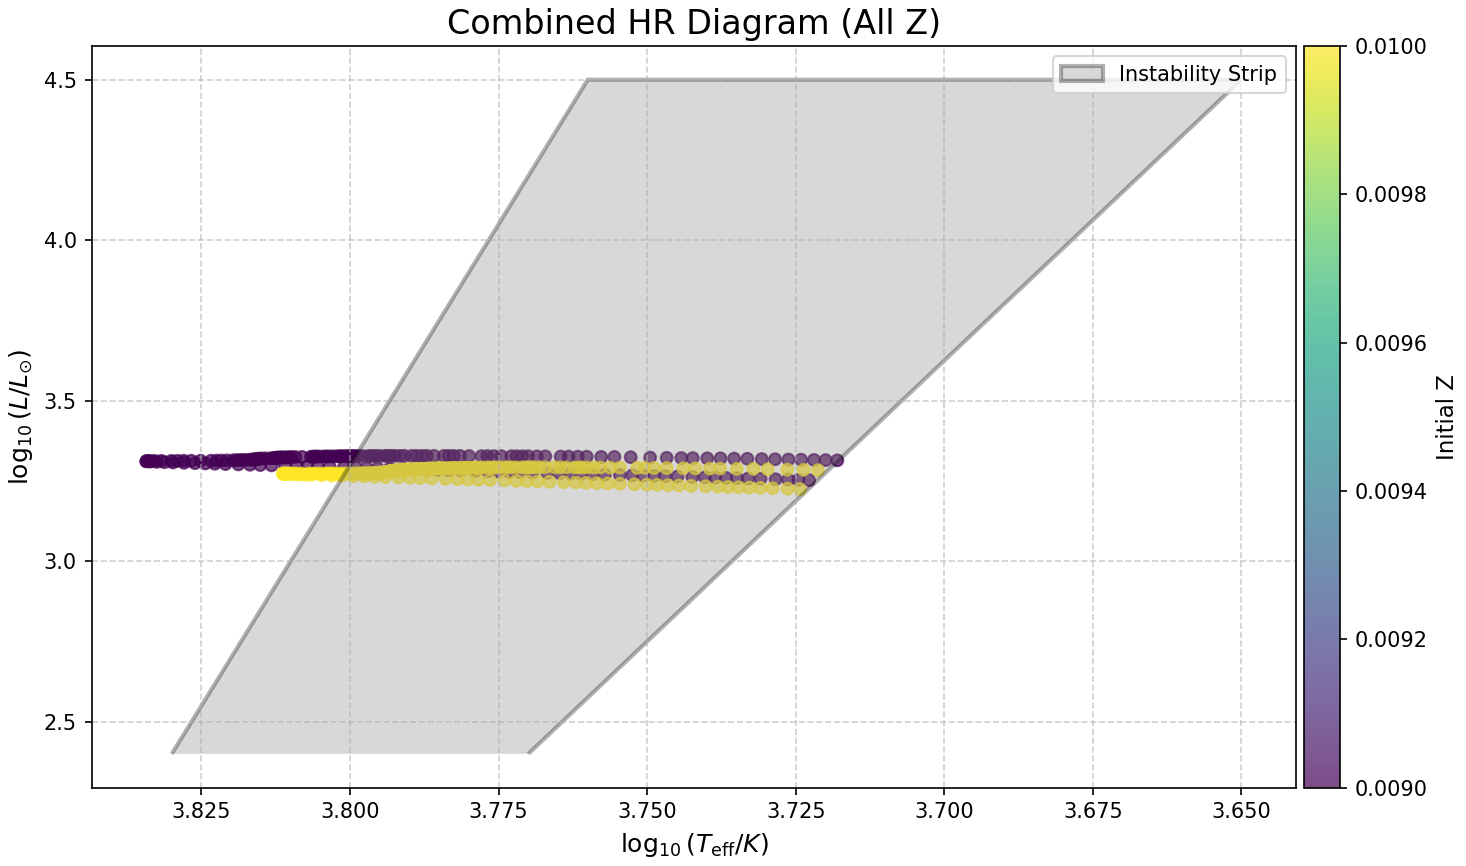

In [7]:
from IPython.display import Image
Image(filename='MESA_grid_base_output/plots/HRD_all_blue_loop_data.png')

**Figure 1:** Aggregated Hertzsprung-Russell Diagram for the 5 Msun models that undergo blue loop evolution. This plot specifically focuses on models that are currently within the blue loop phase and have crossed the red (cool) boundary of the Instability Strip (IS), indicating evolutionary stages relevant for pulsating stars.

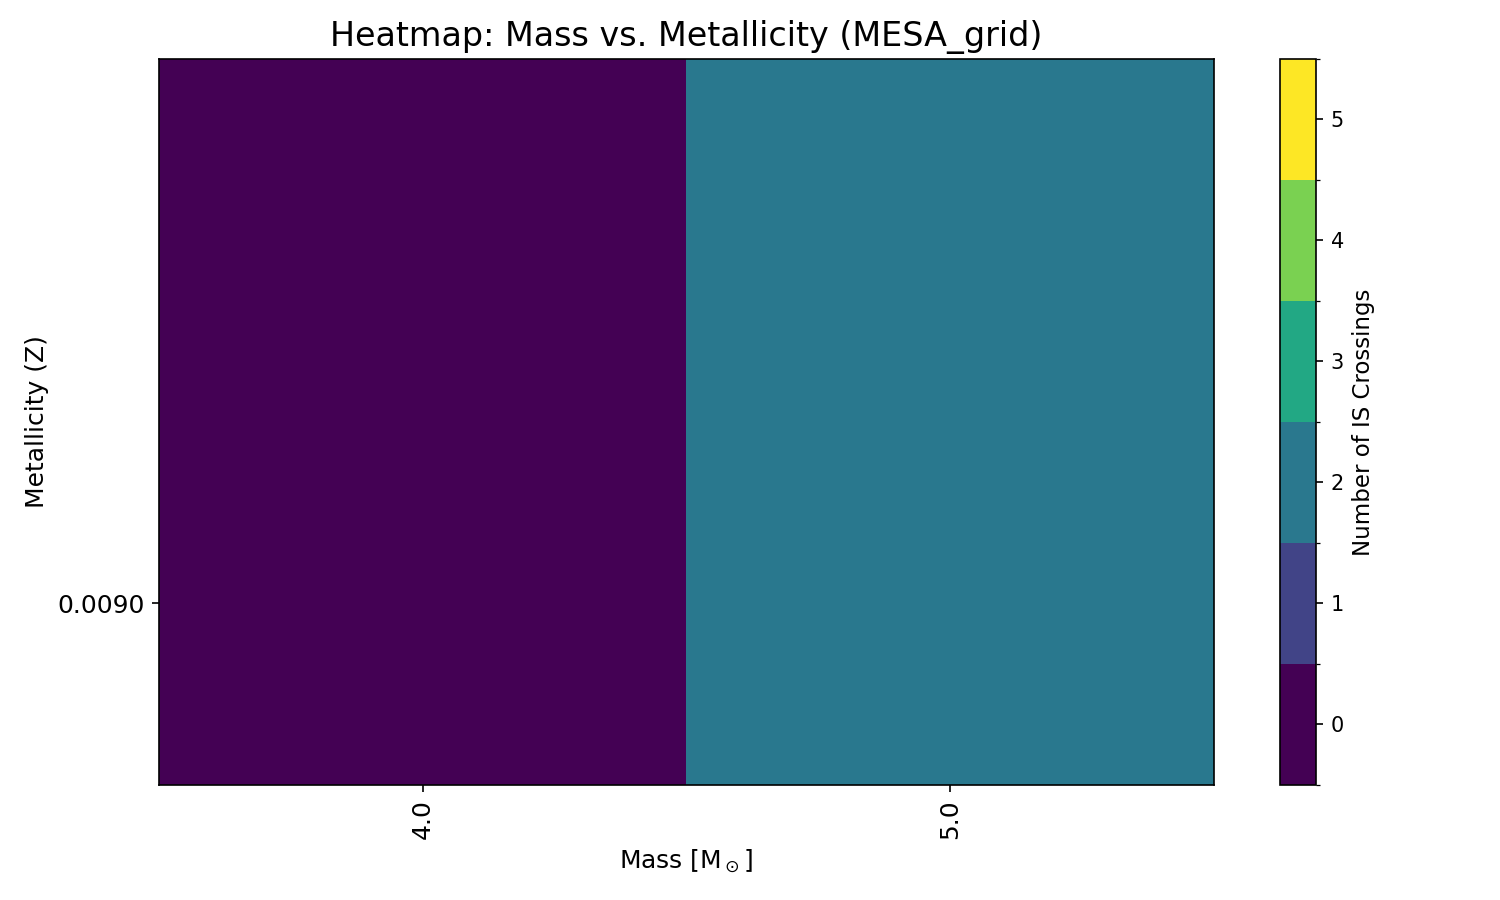

In [8]:
Image(filename='MESA_grid_base_output/plots/mesa_grid_blue_loop_heatmap.png')

**Figure 2:** Heatmap visualizing the number of instability strip crossings for different initial masses and metallicities.

----

#### 3.2. Additional Plots and CSVs


You can find more plots and CSV files in the `example/MESA_grid_base_output/` directory. These include HR diagrams for each metallicity and a color-magnitude diagram (CMD) of the blue loop evolutionary tracks.